# Router Training Notebook

**Purpose**: Train a neural router to select between BM25 and FAISS retrieval backends based on question characteristics.

**Approach**: Use question embeddings + popularity as features to predict which backend will succeed.

**Data Structure**: Question-centric format with one row per question containing all backend results.

In [1]:
# Cell 1: Import dependencies
# Purpose: Load all required libraries for data processing and visualization

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from model_service import RouterService

In [2]:
# Cell 2: Load and restructure data into question-centric format
# Purpose: Transform from (question_id, backend, performance) to (question_id, bm25_performance, faiss_performance, ...)
#          This makes it clear that we're predicting 

MODEL_NAME = 'router_pop_after_bert'

df_raw = pd.read_parquet('data/analysis_dataset.parquet')
df_raw = df_raw[(df_raw['dataset'] != 'fever') & (df_raw['llm'] == 'neo')]

backends_to_train = ['bm25_plus', 'ivfpq_high']
backends_to_eval = ['bm25_plus', 'ivfpq_high', 'zero_shot', 'faiss_hybrid']

df_filtered = df_raw[df_raw['backend'].isin(backends_to_eval)]

questions = df_filtered.pivot_table(
    index='question_id',
    columns='backend',
    values='performance',
    aggfunc='first'
).reset_index()

meta = df_filtered.groupby('question_id').agg({
    'question_text': 'first',
    'popularity': 'first',
    'dataset': 'first',
    'split': 'first'
}).reset_index()

questions = meta.merge(questions, on='question_id')

print(f'Total questions: {len(questions)}')
print(f'Columns: {questions.columns.tolist()}')
print(f'\nSample row:')
print(questions.iloc[0])

Total questions: 41743
Columns: ['question_id', 'question_text', 'popularity', 'dataset', 'split', 'bm25_plus', 'faiss_hybrid', 'ivfpq_high', 'zero_shot']

Sample row:
question_id                                  -1001531070201985556
question_text    where does the permanent fund dividend come from
popularity                                             11851.0625
dataset                                         natural_questions
split                                                       train
bm25_plus                                                   False
faiss_hybrid                                                False
ivfpq_high                                                  False
zero_shot                                                   False
Name: 0, dtype: object


In [3]:
# Cell 3: Prepare training labels from backend performance
# Purpose: For each question, create label vector [bm25_success, faiss_success]
#          If both failed, use uniform [0.5, 0.5] (router should guess randomly)

def create_labels(row, backends):
    labels = [float(row[b]) if pd.notna(row[b]) else 0.0 for b in backends]
    return labels if sum(labels) > 0 else [1.0 / len(backends)] * len(backends)

questions['router_labels'] = questions.apply(
    lambda r: create_labels(r, backends_to_train),
    axis=1
)

train_questions = questions[questions['split'] == 'train'].reset_index(drop=True)
test_questions = questions[questions['split'] == 'test'].reset_index(drop=True)

print(f'Train questions: {len(train_questions)}')
print(f'Test questions: {len(test_questions)}')
print(f'\nExample labels: {train_questions["router_labels"].head(3).tolist()}')

Train questions: 37556
Test questions: 4187

Example labels: [[0.5, 0.5], [0.5, 0.5], [0.5, 0.5]]


In [4]:
# Cell 4: Train router on Modal H100
# Purpose: Send training data to Modal GPU service for fast training
#          Returns trained model weights and training history

service = RouterService()

print('Training router on Modal H100...')
result = service.train(
    train_questions=train_questions['question_text'].tolist(),
    train_popularity=train_questions['popularity'].tolist(),
    train_labels=train_questions['router_labels'].tolist(),
    test_questions=test_questions['question_text'].tolist(),
    test_popularity=test_questions['popularity'].tolist(),
    test_labels=test_questions['router_labels'].tolist(),
    num_classes=len(backends_to_train),
    epochs=80,
    batch_size=32,
    lr=0.001,
    unfreeze_layers=0,  # 0=all frozen, 1=last layer, 2=last 2 layers, 3=last 3 layers
    bert_lr=2e-5        # Learning rate for BERT layers (only used if unfreeze_layers > 0)
)

# Save the trained model
RouterService.save_model(result, f'models/{MODEL_NAME}.pt')
print(f'Model saved to models/{MODEL_NAME}.pt')

print('\nTraining complete!')
print(f'Final train loss: {result["history"]["train_loss"][-1]:.4f}')
print(f'Final train acc: {result["history"]["train_acc"][-1]:.2%}')
print(f'Final test loss: {result["history"]["test_loss"][-1]:.4f}')
print(f'Final test acc: {result["history"]["test_acc"][-1]:.2%}')

Training router on Modal H100...
Model saved to models/router_pop_after_bert.pt

Training complete!
Final train loss: 0.6854
Final train acc: 88.93%
Final test loss: 0.6940
Final test acc: 87.46%


In [5]:
# Cell: Load a previously trained model (optional - skip if you just trained)
# Purpose: Load saved model weights instead of retraining

# result = RouterService.load_model('models/router_latest.pt')
# print('Model loaded!')
# print(f'Model config: {result["model_config"]}')

In [13]:
# Cell 5: Generate router predictions using Modal inference
# Purpose: Use trained router on Modal to predict which backend to use for each test question
#          All other results (BM25, FAISS, Zero-Shot, Hybrid) come directly from dataset

print('Running inference on Modal H100...')
predictions = service.predict(
    questions=test_questions['question_text'].tolist(),
    popularity=test_questions['popularity'].tolist(),
    classifier_state=result['classifier_state'],
    scaler_mean=result['scaler_mean'],
    scaler_scale=result['scaler_scale'],
    model_config=result['model_config'],
    batch_size=64
)

test_questions['router_pred_backend'] = [backends_to_train[p] for p in predictions]

test_questions['router_only'] = test_questions.apply(
    lambda r: r[r['router_pred_backend']] if pd.notna(r.get(r['router_pred_backend'])) else False,
    axis=1
)

eval_questions = test_questions[[
    'question_id', 'dataset', 'popularity',
    'bm25_plus', 'ivfpq_high', 'zero_shot', 'faiss_hybrid',
    'router_only'
]].copy()

eval_questions = eval_questions.dropna(subset=['bm25_plus', 'ivfpq_high', 'zero_shot'])
eval_questions['log_pop'] = np.log10(eval_questions['popularity'] + 1)

print(f'\nEvaluation on {len(eval_questions)} test questions')
print(f'Dataset columns: bm25_plus, ivfpq_high, zero_shot, faiss_hybrid')
print(f'Computed column: router_only')

Running inference on Modal H100...

Evaluation on 4187 test questions
Dataset columns: bm25_plus, ivfpq_high, zero_shot, faiss_hybrid
Computed column: router_only


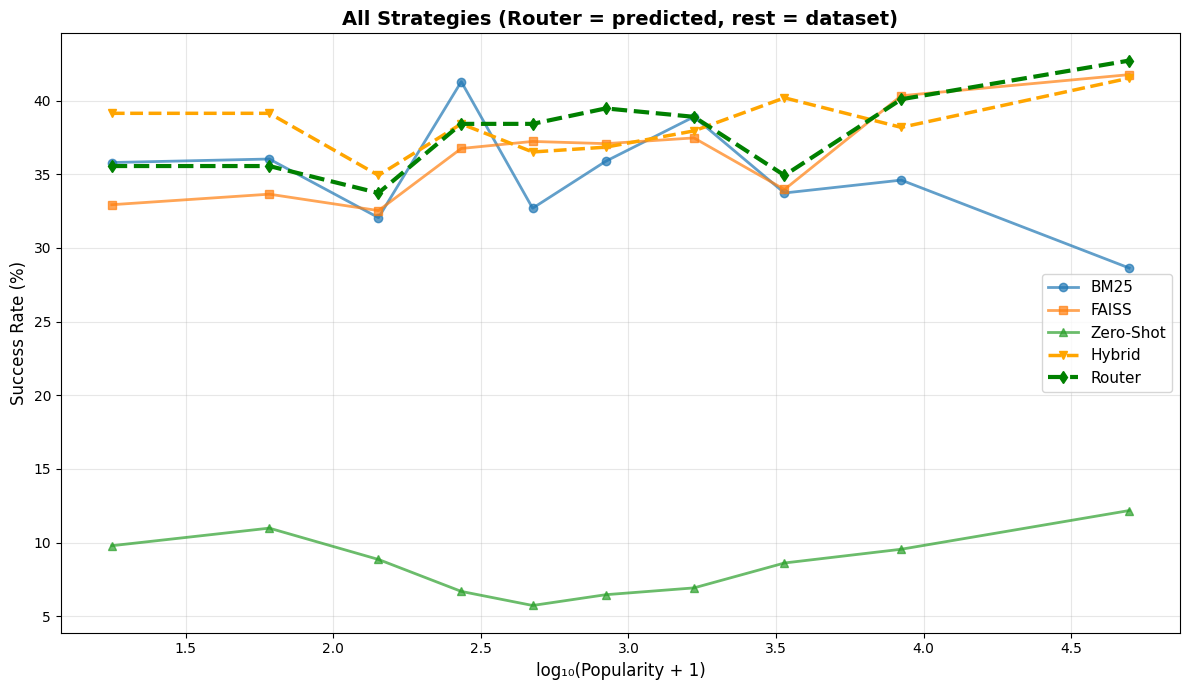

Overall Success Rates (all from dataset except Router):
  BM25:       35.0%
  FAISS:      36.4%
  Zero-Shot:  8.6%
  Hybrid:     38.3% (n=4187)
  Router:     37.8% (predicted)

Router improvement over best single backend (36.4%):
  +1.4%


In [14]:
# Cell 7: Visualize results
# Purpose: Compare all strategies across popularity levels
#          Dataset columns: BM25, FAISS, Zero-Shot, Hybrid (all ground truth from your data)
#          Computed: Router (our trained model's predictions)
#          Question: Can our router match or beat the dataset's hybrid strategy?

bins = pd.qcut(eval_questions['log_pop'], q=10, duplicates='drop')
grouped = eval_questions.groupby(bins)

x = grouped['log_pop'].mean()
y_bm25 = grouped['bm25_plus'].mean() * 100
y_faiss = grouped['ivfpq_high'].mean() * 100
y_zero = grouped['zero_shot'].mean() * 100
y_hybrid_ds = grouped['faiss_hybrid'].mean() * 100
y_router = grouped['router_only'].mean() * 100
plt.figure(figsize=(12, 7))
plt.plot(x, y_bm25, 'o-', label='BM25', linewidth=2, alpha=0.7)
plt.plot(x, y_faiss, 's-', label='FAISS', linewidth=2, alpha=0.7)
plt.plot(x, y_zero, '^-', label='Zero-Shot', linewidth=2, alpha=0.7)
plt.plot(x, y_hybrid_ds, 'v--', label='Hybrid', linewidth=2.5, color='orange')
plt.plot(x, y_router, 'd--', label='Router', linewidth=3, color='green')

plt.xlabel('log₁₀(Popularity + 1)', fontsize=12)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.title('All Strategies (Router = predicted, rest = dataset)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('router_results.png', dpi=150)
plt.show()

eval_subset = eval_questions.dropna(subset=['faiss_hybrid'])

print('Overall Success Rates (all from dataset except Router):')
print(f'  BM25:       {eval_questions["bm25_plus"].mean()*100:.1f}%')
print(f'  FAISS:      {eval_questions["ivfpq_high"].mean()*100:.1f}%')
print(f'  Zero-Shot:  {eval_questions["zero_shot"].mean()*100:.1f}%')
print(f'  Hybrid:     {eval_subset["faiss_hybrid"].mean()*100:.1f}% (n={len(eval_subset)})')
print(f'  Router:     {eval_questions["router_only"].mean()*100:.1f}% (predicted)')

best_baseline = max(
    eval_questions['bm25_plus'].mean(),
    eval_questions['ivfpq_high'].mean(),
    eval_questions['zero_shot'].mean()
) * 100

print(f'\nRouter improvement over best single backend ({best_baseline:.1f}%):')
print(f'  {eval_questions["router_only"].mean()*100 - best_baseline:+.1f}%')

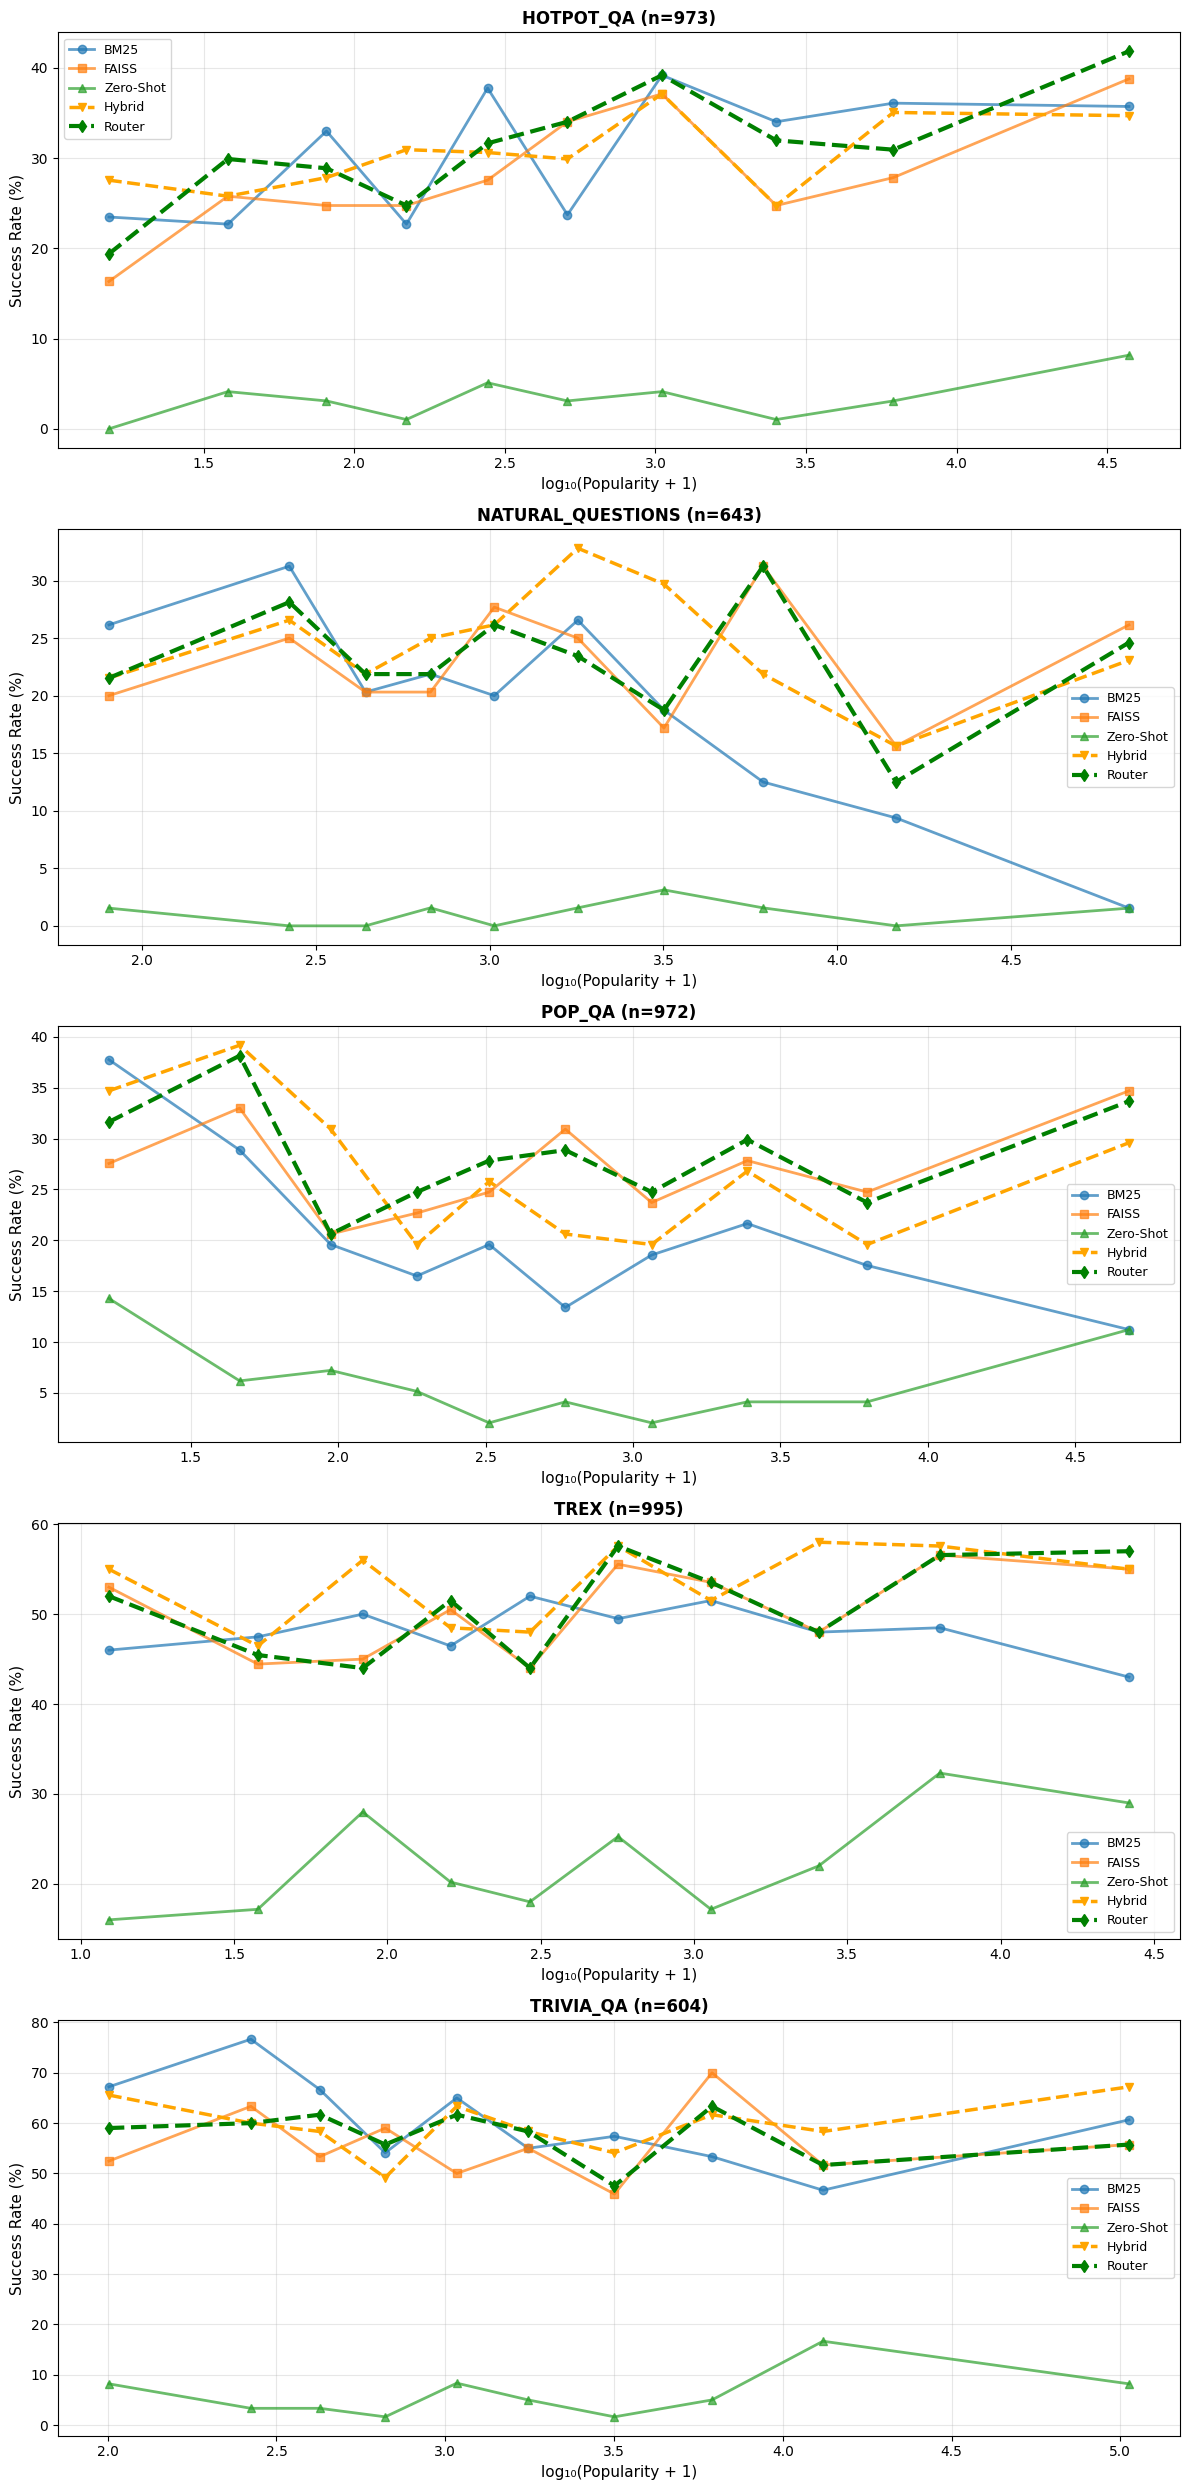

Per-Dataset Success Rates:

HOTPOT_QA (n=973):
  BM25:       30.8%
  FAISS:      28.2%
  Zero-Shot:   3.3%
  Hybrid:     30.4% (n=973)
  Router:     31.2%

NATURAL_QUESTIONS (n=643):
  BM25:       18.8%
  FAISS:      22.9%
  Zero-Shot:   1.1%
  Hybrid:     24.4% (n=643)
  Router:     23.0%

POP_QA (n=972):
  BM25:       20.5%
  FAISS:      27.1%
  Zero-Shot:   6.1%
  Hybrid:     26.6% (n=972)
  Router:     28.4%

TREX (n=995):
  BM25:       48.2%
  FAISS:      50.6%
  Zero-Shot:  22.5%
  Hybrid:     53.4% (n=995)
  Router:     51.0%

TRIVIA_QA (n=604):
  BM25:       60.3%
  FAISS:      55.6%
  Zero-Shot:   6.1%
  Hybrid:     59.6% (n=604)
  Router:     57.5%


In [15]:
# Cell 8: Per-dataset comparison
# Purpose: Break down results by dataset to see where router excels or struggles
#          Shows same comparison (all strategies) but for each dataset individually

datasets = sorted(eval_questions['dataset'].dropna().unique())
n_datasets = len(datasets)

fig, axes = plt.subplots(n_datasets, 1, figsize=(12, 5 * n_datasets))
if n_datasets == 1:
    axes = [axes]

for idx, dataset in enumerate(datasets):
    ds_data = eval_questions[eval_questions['dataset'] == dataset]
    
    if len(ds_data) < 10:
        continue
    
    bins = pd.qcut(ds_data['log_pop'], q=min(10, len(ds_data)//10), duplicates='drop')
    grouped = ds_data.groupby(bins)
    
    x = grouped['log_pop'].mean()
    y_bm25 = grouped['bm25_plus'].mean() * 100
    y_faiss = grouped['ivfpq_high'].mean() * 100
    y_zero = grouped['zero_shot'].mean() * 100
    y_hybrid = grouped['faiss_hybrid'].mean() * 100
    y_router = grouped['router_only'].mean() * 100
    
    ax = axes[idx]
    ax.plot(x, y_bm25, 'o-', label='BM25', linewidth=2, alpha=0.7)
    ax.plot(x, y_faiss, 's-', label='FAISS', linewidth=2, alpha=0.7)
    ax.plot(x, y_zero, '^-', label='Zero-Shot', linewidth=2, alpha=0.7)
    ax.plot(x, y_hybrid, 'v--', label='Hybrid', linewidth=2.5, color='orange')
    ax.plot(x, y_router, 'd--', label='Router', linewidth=3, color='green')
    
    ax.set_xlabel('log₁₀(Popularity + 1)', fontsize=11)
    ax.set_ylabel('Success Rate (%)', fontsize=11)
    ax.set_title(f'{dataset.upper()} (n={len(ds_data)})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('router_per_dataset.png', dpi=150)
plt.show()

print('Per-Dataset Success Rates:')
for dataset in datasets:
    ds_data = eval_questions[eval_questions['dataset'] == dataset]
    ds_hybrid = ds_data.dropna(subset=['faiss_hybrid'])
    
    print(f'\n{dataset.upper()} (n={len(ds_data)}):')
    print(f'  BM25:      {ds_data["bm25_plus"].mean()*100:5.1f}%')
    print(f'  FAISS:     {ds_data["ivfpq_high"].mean()*100:5.1f}%')
    print(f'  Zero-Shot: {ds_data["zero_shot"].mean()*100:5.1f}%')
    print(f'  Hybrid:    {ds_hybrid["faiss_hybrid"].mean()*100:5.1f}% (n={len(ds_hybrid)})')
    print(f'  Router:    {ds_data["router_only"].mean()*100:5.1f}%')

Loading retrieval data...
Calculating Recall@3 for bm25_plus...
Calculating Recall@3 for ivfpq_high...
Calculating Recall@3 for zero_shot...
Calculating Recall@3 for faiss_hybrid...

Recall@3 evaluation on 4187 test questions


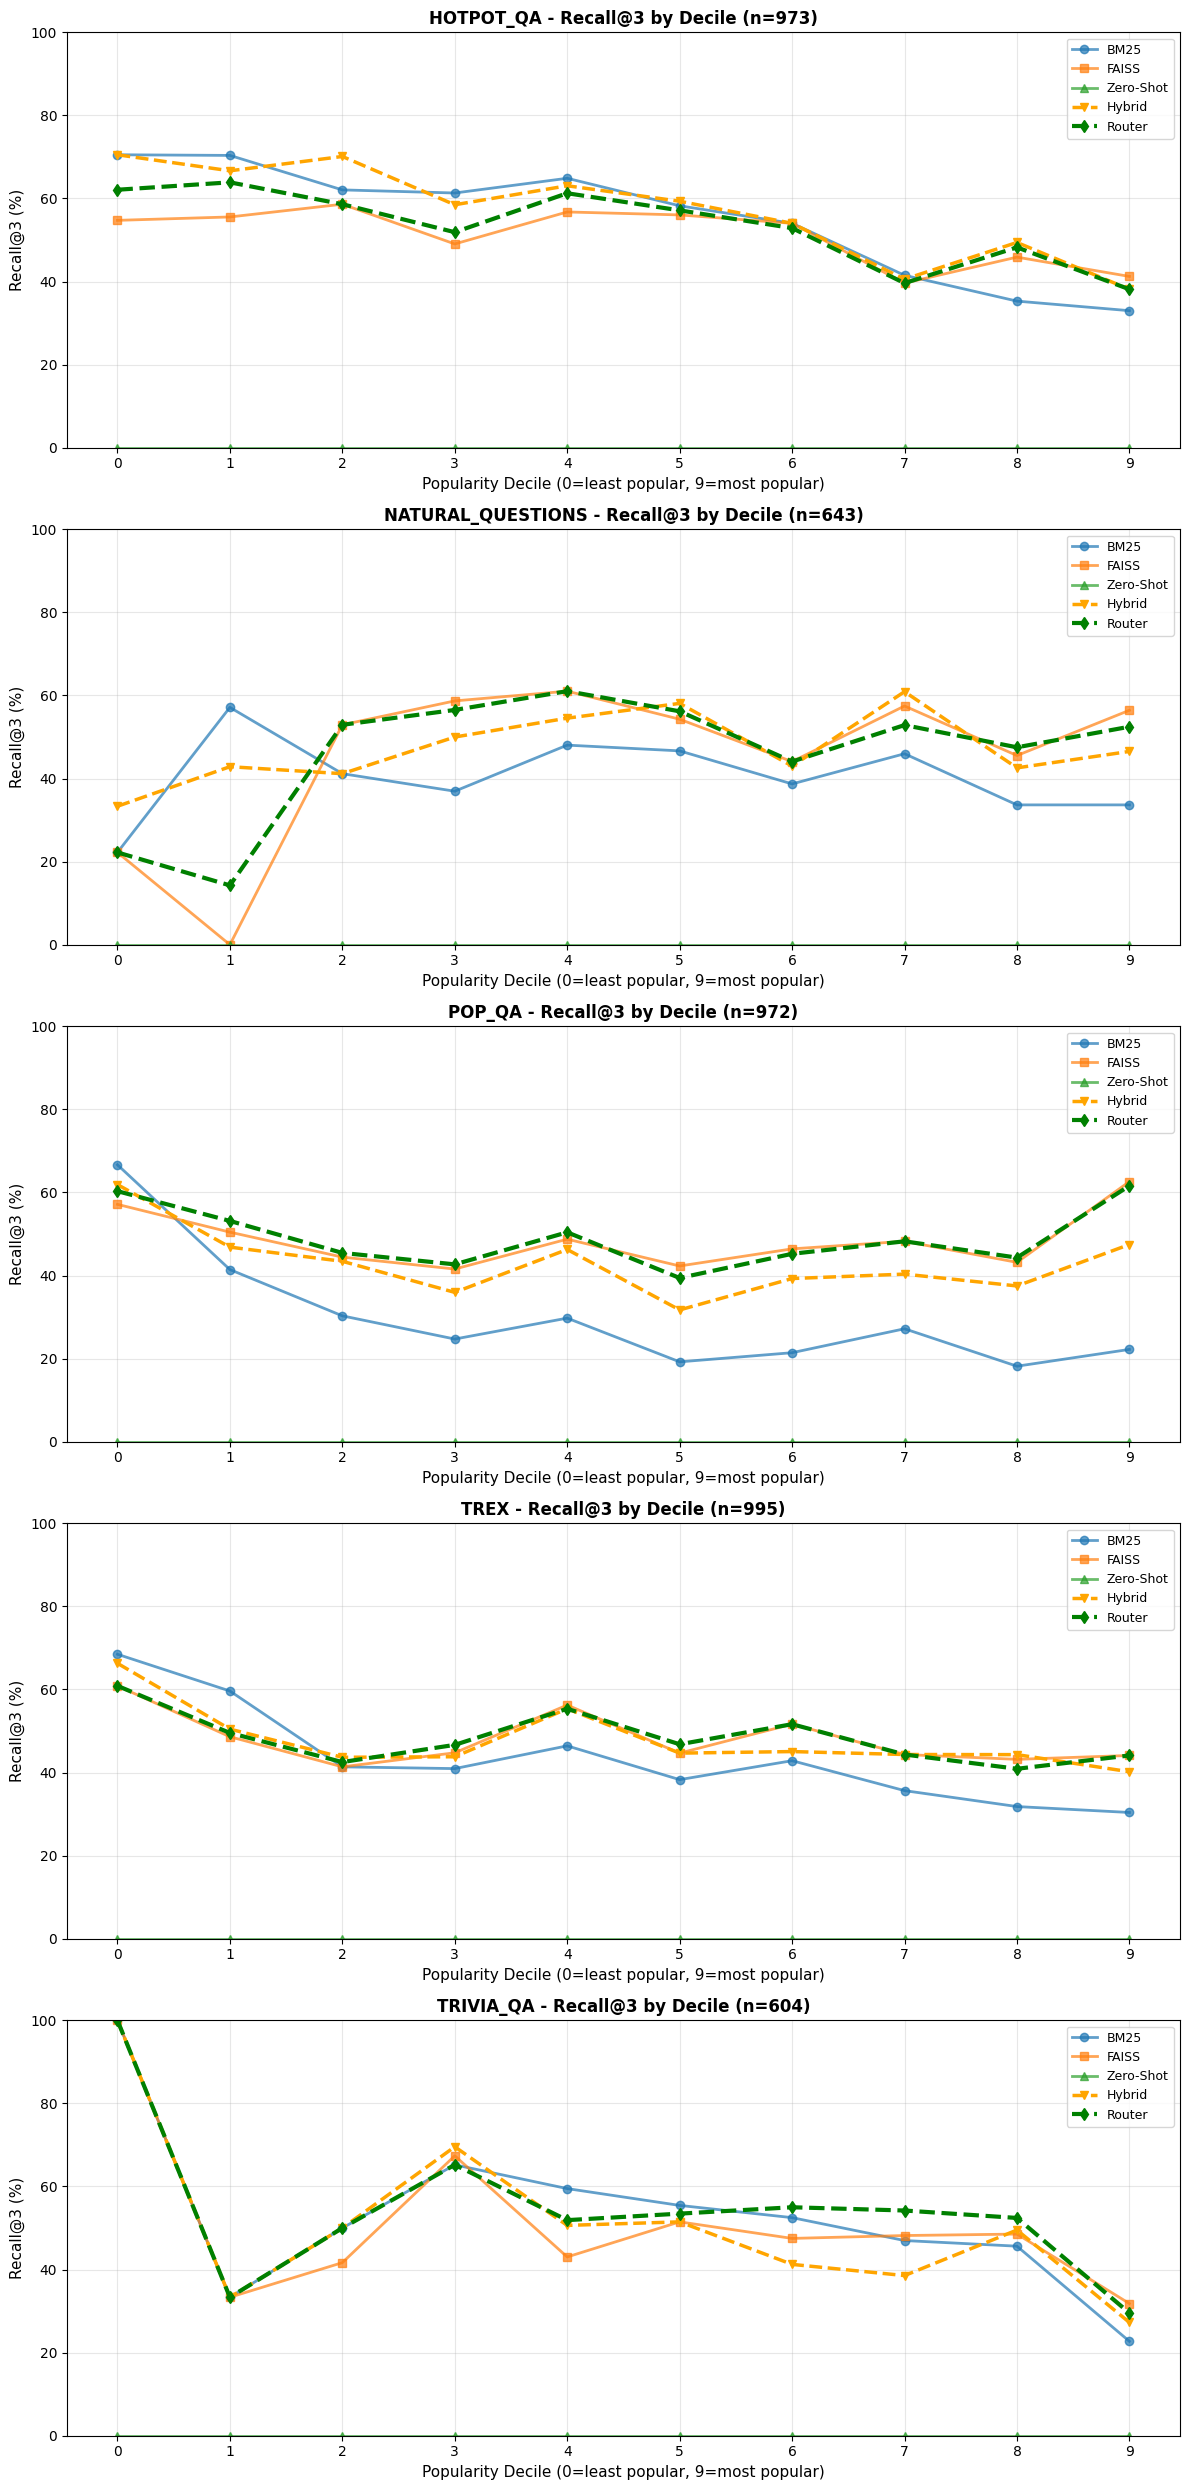


Overall Recall@3 (Test Set):
  BM25_PLUS      :  43.2%
  IVFPQ_HIGH     :  49.3%
  ZERO_SHOT      :   0.0%
  FAISS_HYBRID   :  48.8%
  ROUTER:          50.5%

Per-Dataset Recall@3:

HOTPOT_QA (n=973):
  BM25_PLUS      :  55.5%
  IVFPQ_HIGH     :  51.1%
  ZERO_SHOT      :   0.0%
  FAISS_HYBRID   :  57.0%
  ROUTER:          53.4%

NATURAL_QUESTIONS (n=643):
  BM25_PLUS      :  40.4%
  IVFPQ_HIGH     :  52.3%
  ZERO_SHOT      :   0.0%
  FAISS_HYBRID   :  50.1%
  ROUTER:          51.6%

POP_QA (n=972):
  BM25_PLUS      :  29.1%
  IVFPQ_HIGH     :  48.4%
  ZERO_SHOT      :   0.0%
  FAISS_HYBRID   :  42.6%
  ROUTER:          48.9%

TREX (n=995):
  BM25_PLUS      :  43.6%
  IVFPQ_HIGH     :  48.0%
  ZERO_SHOT      :   0.0%
  FAISS_HYBRID   :  47.8%
  ROUTER:          48.3%

TRIVIA_QA (n=604):
  BM25_PLUS      :  48.5%
  IVFPQ_HIGH     :  47.0%
  ZERO_SHOT      :   0.0%
  FAISS_HYBRID   :  45.7%
  ROUTER:          50.7%

Recall@3 by Decile (Overall Test Set):

Decile 0 (n=262):
  BM25_PLUS   

In [20]:
# Cell 9: Per-dataset Recall@3 comparison by popularity decile
# Purpose: Show retrieval quality (Recall@3) across popularity deciles for each dataset
#          Includes Router predictions to see if it selects the backend with better retrieval

import numpy as np

# Calculate Recall@3 for a single row
def calculate_recall_at_k(row, k=3):
    try:
        wiki_id = row['wikipedia_id']
        retrieved_ids = row['retrieved_doc_ids']
        
        # Handle missing data
        if wiki_id is None or (isinstance(wiki_id, float) and np.isnan(wiki_id)):
            return 0.0
        if retrieved_ids is None:
            return 0.0
        if not isinstance(retrieved_ids, (list, np.ndarray)):
            return 0.0
        if len(retrieved_ids) == 0:
            return 0.0
        
        # Check if wiki_id is in top k
        wiki_id_str = str(wiki_id)
        retrieved_strs = [str(x) for x in retrieved_ids[:k]]
        return 1.0 if wiki_id_str in retrieved_strs else 0.0
    except Exception as e:
        return 0.0

# Load full dataset with retrieval information
print('Loading retrieval data...')
df_full = pd.read_parquet('data/analysis_dataset.parquet')
df_full = df_full[(df_full['dataset'] != 'fever') & (df_full['llm'] == 'neo')]

# Calculate recall for each backend
backends_for_recall = ['bm25_plus', 'ivfpq_high', 'zero_shot', 'faiss_hybrid']

recall_data = []
for backend in backends_for_recall:
    if backend not in df_full['backend'].values:
        print(f'Skipping {backend} - not in dataset')
        continue
    print(f'Calculating Recall@3 for {backend}...')
    backend_df = df_full[df_full['backend'] == backend].copy()
    backend_df['recall_at_3'] = backend_df.apply(calculate_recall_at_k, axis=1)
    backend_df['backend_col'] = backend
    recall_data.append(backend_df[['question_id', 'backend_col', 'recall_at_3', 'dataset', 'popularity', 'decile', 'split']])

recall_df = pd.concat(recall_data, ignore_index=True)

# Pivot to question-centric format
recall_pivot = recall_df.pivot_table(
    index='question_id',
    columns='backend_col',
    values='recall_at_3',
    aggfunc='first'
).reset_index()

# Merge with metadata
meta_recall = recall_df.groupby('question_id').agg({
    'dataset': 'first',
    'popularity': 'first',
    'decile': 'first',
    'split': 'first'
}).reset_index()

recall_questions = meta_recall.merge(recall_pivot, on='question_id')

# Merge with test_questions to get router predictions
if 'router_pred_backend' in test_questions.columns:
    router_preds = test_questions[['question_id', 'router_pred_backend']].copy()
    recall_questions = recall_questions.merge(router_preds, on='question_id', how='left')
    
    # Calculate router's recall (what backend it chose)
    def get_router_recall(row):
        backend = row.get('router_pred_backend')
        if backend and backend in row:
            return row[backend]
        return 0.0
    
    recall_questions['router_recall'] = recall_questions.apply(get_router_recall, axis=1)

# Filter to test set
recall_test = recall_questions[recall_questions['split'] == 'test'].copy()

print(f'\nRecall@3 evaluation on {len(recall_test)} test questions')

# Plot per-dataset Recall@3 by decile
datasets = sorted(recall_test['dataset'].dropna().unique())
n_datasets = len(datasets)

fig, axes = plt.subplots(n_datasets, 1, figsize=(12, 5 * n_datasets))
if n_datasets == 1:
    axes = [axes]

for idx, dataset in enumerate(datasets):
    ds_data = recall_test[recall_test['dataset'] == dataset]
    
    if len(ds_data) < 10:
        continue
    
    # Group by decile
    grouped = ds_data.groupby('decile')
    
    # Get decile values (0-9)
    x = sorted(ds_data['decile'].unique())
    
    ax = axes[idx]
    
    # Plot all backends that exist
    if 'bm25_plus' in ds_data.columns:
        y_bm25 = [grouped.get_group(d)['bm25_plus'].mean() * 100 if d in grouped.groups else np.nan for d in x]
        ax.plot(x, y_bm25, 'o-', label='BM25', linewidth=2, alpha=0.7)
    
    if 'ivfpq_high' in ds_data.columns:
        y_faiss = [grouped.get_group(d)['ivfpq_high'].mean() * 100 if d in grouped.groups else np.nan for d in x]
        ax.plot(x, y_faiss, 's-', label='FAISS', linewidth=2, alpha=0.7)
    
    if 'zero_shot' in ds_data.columns:
        y_zero = [grouped.get_group(d)['zero_shot'].mean() * 100 if d in grouped.groups else np.nan for d in x]
        ax.plot(x, y_zero, '^-', label='Zero-Shot', linewidth=2, alpha=0.7)
    
    if 'faiss_hybrid' in ds_data.columns:
        y_hybrid = [grouped.get_group(d)['faiss_hybrid'].mean() * 100 if d in grouped.groups else np.nan for d in x]
        ax.plot(x, y_hybrid, 'v--', label='Hybrid', linewidth=2.5, color='orange')
    
    if 'router_recall' in ds_data.columns:
        y_router = [grouped.get_group(d)['router_recall'].mean() * 100 if d in grouped.groups else np.nan for d in x]
        ax.plot(x, y_router, 'd--', label='Router', linewidth=3, color='green')
    
    ax.set_xlabel('Popularity Decile (0=least popular, 9=most popular)', fontsize=11)
    ax.set_ylabel('Recall@3 (%)', fontsize=11)
    ax.set_title(f'{dataset.upper()} - Recall@3 by Decile (n={len(ds_data)})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 100])
    ax.set_xticks(x)

plt.tight_layout()
plt.savefig('router_recall_at_3_per_dataset_by_decile.png', dpi=150)
plt.show()

# Print overall Recall@3 statistics
print('\nOverall Recall@3 (Test Set):')
for backend in backends_for_recall:
    if backend in recall_test.columns:
        recall_score = recall_test[backend].mean() * 100
        print(f'  {backend.upper():15s}: {recall_score:5.1f}%')

if 'router_recall' in recall_test.columns:
    recall_score = recall_test['router_recall'].mean() * 100
    print(f'  ROUTER:         {recall_score:5.1f}%')

print('\nPer-Dataset Recall@3:')
for dataset in datasets:
    ds_data = recall_test[recall_test['dataset'] == dataset]
    
    print(f'\n{dataset.upper()} (n={len(ds_data)}):')
    for backend in backends_for_recall:
        if backend in ds_data.columns:
            recall_score = ds_data[backend].mean() * 100
            print(f'  {backend.upper():15s}: {recall_score:5.1f}%')
    
    if 'router_recall' in ds_data.columns:
        recall_score = ds_data['router_recall'].mean() * 100
        print(f'  ROUTER:         {recall_score:5.1f}%')

print('\nRecall@3 by Decile (Overall Test Set):')
for decile in sorted(recall_test['decile'].unique()):
    decile_data = recall_test[recall_test['decile'] == decile]
    print(f'\nDecile {decile} (n={len(decile_data)}):')
    for backend in backends_for_recall:
        if backend in decile_data.columns:
            recall_score = decile_data[backend].mean() * 100
            print(f'  {backend.upper():15s}: {recall_score:5.1f}%')
    if 'router_recall' in decile_data.columns:
        recall_score = decile_data['router_recall'].mean() * 100
        print(f'  ROUTER:         {recall_score:5.1f}%')